In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

In [4]:
df = pd.read_csv('PPLC_Issued_Building_Permits_5423838102305819771.csv')

## Overview: Key Metrics
This dataset informs us about how Halifax has evolved over the last **five and half years** in terms of construction projects. 

In this analysis, we find information regarding building permits issued by **HRM Planning and Development**, which include $30$ different Categories. Some of these categories are: Permit Number, Date it was issued, Type of Building (Commercial, Industrial, Agriculture, etc..), and Project Valuation

In [31]:
df.head()

,Permit_Number,Date_of_Submission,Date_of_Permit_Issuance,Completed_Date,Expiration_Date,Permit_Name,Work_Type,Primary_Work_Scope,Permit_Status,Civic_ID,...,Building_Footprint_Area,Number_of_Storeys,Work_Description,Active_Parcel,Date_Inspection_Completed,District,Inspection_Outcome,Overall_Building_Height,Net_New_Units,OBJECTID
0,BPRES-2022-11152,2022-08-18 12:00:00,NaN,9/15/2022 12:00:00 PM,NaN,Residential Building Permit,Renovation,Renovation,Withdrawn,98021.0,...,40.00,1.0,Nano-brewery,Y,NaN,District 02,NaN,3.46,0,1
1,BPCOM-2024-10217,2024-08-27 12:00:00,9/3/2024 12:00:00 PM,11/26/2025 12:00:00 PM,9/3/2026 12:00:00 PM,Mixed Use & Commercial Building Permit,Renovation,Renovation,Completed,164065.0,...,1775.00,5.0,Completing level 4 & level 5 of the Dalhousie ...,Y,2025-11-26 12:00:00,District 07,Passed,22.00,0,2
2,BPRES-2024-11101,2024-08-16 12:00:00,8/23/2024 12:00:00 PM,NaN,8/23/2026 12:00:00 PM,Residential Building Permit,New Building,New Building,Issued,28713.0,...,71.35,2.0,Construct garage,Y,2025-01-08 12:00:00,District 13,Passed,6.80,0,3
3,BP-2021-10268,2021-06-03 12:00:00,8/23/2021 12:00:00 PM,NaN,9/22/2025 12:00:00 PM,Residential Building Permit,New Building,New Building,Expired,173581.0,...,599.00,1.0,PID 41496449 (Building 3)\r\r\nConstruction of...,Y,2022-06-24 12:00:00,District 16,Failed,4.00,4,4
4,BPRES-2021-17351,2021-10-12 12:00:00,12/14/2021 12:00:00 PM,NaN,12/14/2023 12:00:00 PM,Residential Building Permit,Renovation,Renovation,Expired,34275.0,...,230.00,2.0,"-HOME RENO\r\r\n-REMOVAL OF POSTS, WHICH WILL ...",Y,2022-01-14 12:00:00,District 14,Partially Passed,5.00,0,5


### Table Info
Below is the list of all 30 categories. From this, we know that there are $18110$ rows of information/pertmit data.

The table below shows the name of the category, how many cells in each colum have a value (are not-null), and their data type (which is either string, integer, or float)

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18110 entries, 0 to 18109
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Permit_Number                18110 non-null  str           
 1   Date_of_Submission           18038 non-null  datetime64[us]
 2   Date_of_Permit_Issuance      15718 non-null  str           
 3   Completed_Date               10276 non-null  str           
 4   Expiration_Date              15716 non-null  str           
 5   Permit_Name                  18110 non-null  str           
 6   Work_Type                    18110 non-null  str           
 7   Primary_Work_Scope           18110 non-null  str           
 8   Permit_Status                18110 non-null  str           
 9   Civic_ID                     17680 non-null  float64       
 10  Civic_Number                 17700 non-null  str           
 11  Street_Name                  17700 non-null  str    

#### Type of Structure:
Tells us the type of the construction permit, whether it's for a a townhouse, for commercial use or agriculture. 

We see that **38.54%** of permit requests submitted, which is the majority, were for Single Detached Houses. This shows that single family homes are still popular.

Commercial: **13.2%**
<br>Institutional and Governmental: **1.07%**
<br>Agriculture: **0.12%**

In [33]:
df['Type_of_Structure'].value_counts()

Type_of_Structure
Dwelling - Single Detached                6980
Accessory Structure                       2949
Dwelling - Multiple Units                 2662
Commercial                                2395
Dwelling - Backyard Suite                  803
Dwelling - Semi-Detached                   783
Mixed Use - Residential & Other Use(s)     664
Dwelling - Townhouse                       464
Institutional and Governmental             193
Industrial                                 118
Dwelling - Seasonal                         75
Agriculture                                 21
Aquaculture                                  3
Name: count, dtype: int64

### Type of Occupany:

Tells us what the building is intended to be used for. Some key metrics are as follows:

Residential Use: **66.09%** 
<br>Office work: **3.93%**
<br>Restaurants: **3.93%**
<br>Parking Structures: **1.45%**

In [34]:
df['Occupancy_Type'].value_counts()

Occupancy_Type
Residential Use                     11969
Secondary Suite                      1214
Office                                713
Backyard Suite                        654
Garage                                602
Retail Use                            601
Restaurant                            453
Storage / Warehouse                   332
Parking Structure                     262
Recreation Use                        240
Service Use                           150
Clinic                                145
Utility Use                            99
Manufacturing / Processing Use         86
Care Use                               81
Hotel / Motel                          66
Religious Institution                  54
Motor Vehicle Related Use              47
Resource Use                           43
Post-Secondary Institution             41
Farming Use                            33
Shared Housing                         31
Drinking Establishment                 28
Arts & Culture     

### Estimated Project Value

The total estimated project value is: $\$26,064,214,296.19$

This translates to **$26 billion** across all 18,110 permits over 5.5 years,  a genuinely striking number!

In [35]:
print(f"Total Value: ${df['Estimated_Project_Value'].sum():,.2f}")

Total Value: $26,064,214,296.19


### Date Range

All permits are in the range of the following dates:

Oldest being submitted on **15th Dec 2020** and latest on **9th Jun 2026**

In [36]:
df['Date_of_Submission'] = pd.to_datetime(df['Date_of_Submission'])

In [37]:
print(f"{df['Date_of_Submission'].min()} --- {df['Date_of_Submission'].max()}")

2020-12-15 12:00:00 --- 2026-06-09 12:00:00


***
## Detailed Analysis: Geographic Trends

In [59]:
df['Community'].value_counts().head(10)

Community
HALIFAX             4512
DARTMOUTH           2300
BEDFORD             1240
HAMMONDS PLAINS      677
MIDDLE SACKVILLE     647
TIMBERLEA            503
BEECHVILLE           422
LOWER SACKVILLE      410
FALL RIVER           397
BEAVER BANK          366
Name: count, dtype: int64

In [102]:
sum_by_group = df.groupby('Community')['Estimated_Project_Value'].sum()
top_10 = sum_by_group.sort_values(ascending = False).head(10)
print(top_10)

Community
HALIFAX             1.120189e+10
DARTMOUTH           5.553082e+09
BEDFORD             2.118679e+09
MYERS POINT         7.822089e+08
WESTPHAL            5.602954e+08
LOWER SACKVILLE     4.710627e+08
HAMMONDS PLAINS     4.600522e+08
MIDDLE SACKVILLE    3.306365e+08
FALL RIVER          3.221864e+08
BEECHVILLE          3.190084e+08
Name: Estimated_Project_Value, dtype: float64


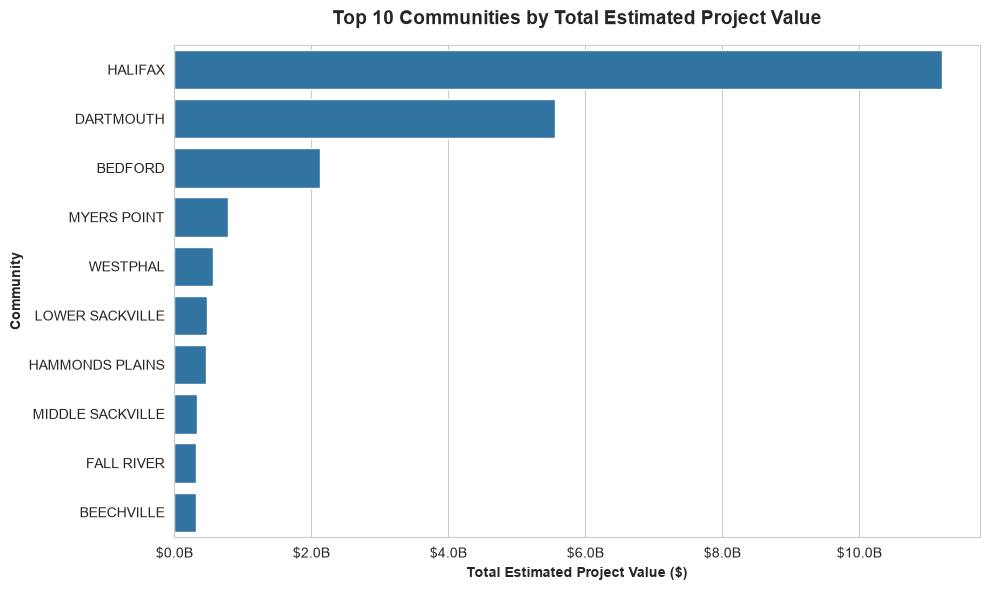

In [132]:
def billions(x, pos):
    return f'${x/1e9:.1f}B'

plt.figure(figsize = (10,6))
sns.set_style("whitegrid")
sns.barplot(x = top_10.values, y = top_10.index)
plt.title("Top 10 Communities by Total Estimated Project Value", fontsize = 14, fontweight = 'bold', pad = 15)
plt.xlabel("Total Estimated Project Value ($)", fontweight = 'bold')
plt.ylabel("Community", fontweight = 'bold')

plt.gca().xaxis.set_major_formatter(FuncFormatter(billions))
plt.tight_layout()
plt.show()